# `rvcadence` quickstart demo

An elaborated, runnable version of the examples in the README, with visual
outputs, using `rvcadence.plotting` throughout. Covers:

1. Basic scheduling from hand-typed windows
2. Multi-planet phase coverage (worst-case aggregation)
3. Astropy-based visibility — resolving a target/site by name. Fully
   self-contained from here on: its own season bounds, its own target/site,
   its own illustrative orbital period. Nothing from Section 1's hand-typed
   windows or example planet is reused.
4. Final calendar view — moon-avoidance + visibility only (astropy decides
   what's observable; no hand-typed windows anywhere in this section), plus
   two bonus diagnostics: altitude-threshold sensitivity, and greedy vs.
   random phase coverage
5. Mid-campaign scheduling — feeding already-observed epochs back in as
   locked dates
6. Tuning the score — the `weights`/`planet_weights` knobs, and whether the
   cadence aliases the planet signal onto stellar rotation

Needs `pip install rvcadence` to run.

In [1]:
from datetime import date, timedelta

import matplotlib.pyplot as plt
import numpy as np

from rvcadence import (
    is_visible,
    plan_calendar,
    resolve_site_name,
    resolve_target_name,
    target_transit_time,
    visibility_allowed_offsets,
)
from rvcadence.plotting import (
    plot_altitude_sensitivity,
    plot_constraint_breakdown,
    plot_coverage_vs_n,
    plot_greedy_vs_random,
    plot_night_availability,
    plot_phase_coverage,
    plot_phase_vs_rotation_phase,
    plot_staralt,
    plot_summary,
    plot_timeline,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 1. Basic quickstart — hand-typed windows

Straight from the README: schedule 20 observations of a 9.53 d planet across
two visibility windows, phased against a 12.45 d stellar rotation period.

In [2]:
season_start = date(2026, 5, 1)
season_end = date(2027, 4, 30)
period_d = 9.53
p_rot_d = 12.45

result = plan_calendar(
    n_obs=20,
    periods_d=period_d,
    season_start=season_start,
    season_end=season_end,
    rotation_period_d=p_rot_d,
    windows="2026-05-01 to 2026-05-19; 2026-07-29 to 2027-04-30",
)

print(f"{len(result.dates)} dates scheduled")
print(f"median gap: {result.median_gap_d} d, mean gap: {result.mean_gap_d} d")
result.dates


20 dates scheduled
median gap: 14.0 d, mean gap: 19.157894736842106 d


[datetime.date(2026, 5, 1),
 datetime.date(2026, 5, 10),
 datetime.date(2026, 8, 7),
 datetime.date(2026, 8, 28),
 datetime.date(2026, 8, 29),
 datetime.date(2026, 9, 7),
 datetime.date(2026, 9, 10),
 datetime.date(2026, 9, 28),
 datetime.date(2026, 10, 9),
 datetime.date(2026, 10, 26),
 datetime.date(2026, 11, 10),
 datetime.date(2026, 12, 29),
 datetime.date(2027, 1, 7),
 datetime.date(2027, 1, 27),
 datetime.date(2027, 2, 9),
 datetime.date(2027, 3, 8),
 datetime.date(2027, 3, 22),
 datetime.date(2027, 3, 31),
 datetime.date(2027, 4, 1),
 datetime.date(2027, 4, 30)]

### Visualizing the schedule

Two views of the same result: a **timeline** (where in the season the
observations fall, relative to the requested windows) and a **phase-coverage**
plot (where the planet's orbital phase and the stellar-rotation phase land at
each chosen date — the two should spread out fairly evenly if the greedy
algorithm is doing its job).

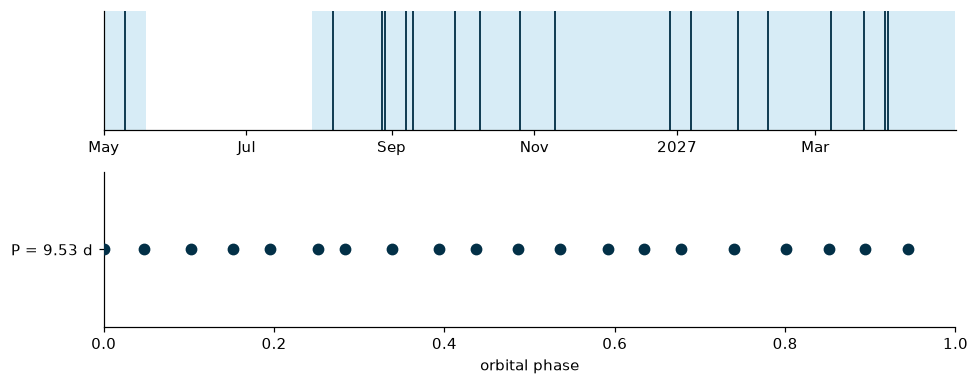

In [3]:
windows = [(date(2026, 5, 1), date(2026, 5, 19)), (date(2026, 7, 29), date(2027, 4, 30))]

fig, axes = plt.subplots(2, 1, figsize=(9, 3.6), gridspec_kw={"height_ratios": [1, 1.3]})
plot_timeline(result, ax=axes[0], windows=windows)
plot_phase_coverage(result, ax=axes[1])
fig.tight_layout()
plt.show()


## 2. Multi-planet phase coverage

For a two-planet system, `periods_d` takes a list. Coverage at each greedy
step is optimized for the **worst-covered** planet, not an average — so one
well-phased planet can't hide a poorly-phased one. We can see this directly
by phase-folding the *same* schedule against both periods.

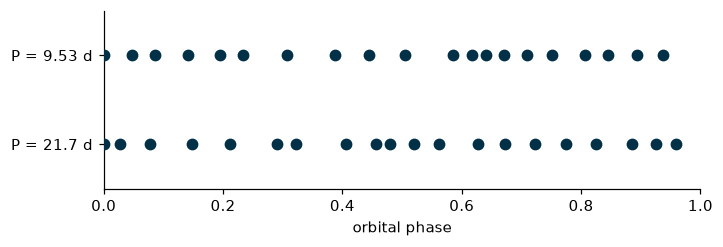

median gap: 15.0 d, mean gap: 19.157894736842106 d


In [4]:
periods_multi = [9.53, 21.7]

result_multi = plan_calendar(
    n_obs=20,
    periods_d=periods_multi,
    season_start=season_start,
    season_end=season_end,
)

plot_phase_coverage(result_multi)
plt.show()

print(f"median gap: {result_multi.median_gap_d} d, mean gap: {result_multi.mean_gap_d} d")


## 3. Astropy-based visibility — resolve a target and site by name

No more hand-typing visibility windows: give `rvcadence` a target name and an
observatory name, and it resolves both (printing the resolved coordinates for
confirmation) and computes visibility itself — a target is "visible" on a
given night if there is *any* instant when it clears `min_altitude_deg` while
the Sun is below `twilight_sun_alt_deg`, sampled across the full night.

In [5]:
# New season bounds, target, and site from here on -- though not fully
# isolated from earlier cells: Section 6 later reuses p_rot_d (Section 1)
# and periods_multi (Section 2).
season_start = date(2026, 5, 1)
season_end = date(2027, 4, 30)
demo_period_d = 9.53  # illustrative only -- not K2-182's real orbital period

target_name = "K2-182"
site_name = "Paranal"
target_coord = resolve_target_name(target_name)
observer_location = resolve_site_name(site_name)


Resolved target 'K2-182' to 08h40m43.2795984s +10d58m58.599516s (ICRS)
Resolved site 'Paranal' to lat=-24.6274, lon=-70.4050, height=2669 m


### How much does each astropy constraint remove on its own?

No hand-typed windows here — the baseline is simply the full program
duration (`season_start` to `season_end`, no holes). What's *not* observable
is determined entirely by astropy: moon-avoidance and visibility
(altitude + twilight, sampled across the full night).

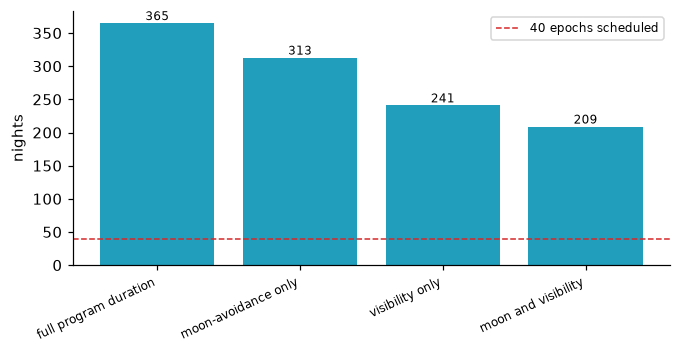

In [6]:
from rvcadence.moon import moon_allowed_offsets

n_days = (season_end - season_start).days + 1
all_nights = set(range(n_days))  # full program duration, no hand-typed holes

moon_allowed = set(moon_allowed_offsets(season_start, season_end, target_coord, observer_location, 30.0))
vis_allowed = set(visibility_allowed_offsets(season_start, season_end, target_coord, observer_location))

counts = {
    "full program duration": len(all_nights),
    "moon-avoidance only": len(moon_allowed),
    "visibility only": len(vis_allowed),
    "moon and visibility": len(moon_allowed & vis_allowed),
}

preview = plan_calendar(
    n_obs=40, periods_d=demo_period_d,
    season_start=season_start, season_end=season_end,
)
plot_constraint_breakdown(preview, counts=counts)
plt.show()


### A night-by-night airmass ("staralt") chart

For a *fixed* target and site, the altitude reached at true transit is
geometrically constant (`90 deg - |lat - dec|`) — it does not vary with the
season. What varies is *when in the night* transit happens, and therefore
whether it falls in daylight, twilight, or full darkness. A single
"altitude at transit" number per night is therefore a flat line and not
useful; the informative view is airmass as a function of both night and
time-of-night, masked to when it's actually usable (dark, and Moon far
enough away) — the classic "staralt" chart. Color = airmass (lower =
better); a pixel is only colored if that night+time is dark, the Moon is at
least `min_moon_sep_deg` away, and the altitude is at or above
`min_altitude_deg` (i.e. airmass <= 2) — nothing more, nothing less. Moon
separation is evaluated once per night, at local midnight — the same
convention `plan_calendar()`/`moon_allowed_offsets()` use.


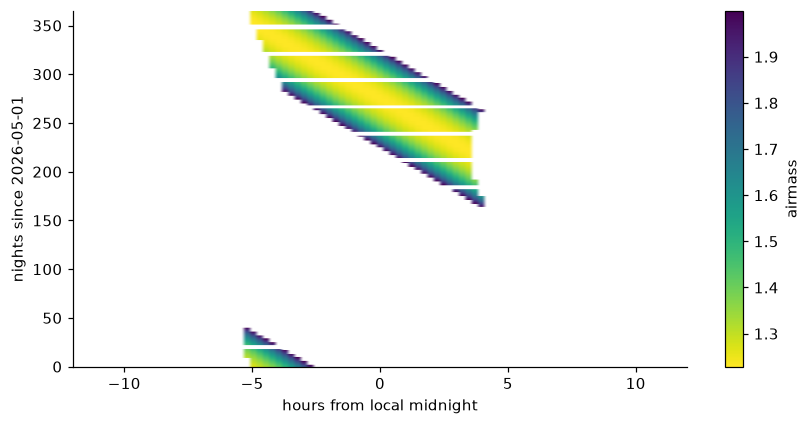

In [7]:
plot_staralt(
    preview,
    target_coord=target_coord,
    observer_location=observer_location,
    min_altitude_deg=30.0,
    min_moon_sep_deg=30.0,
)
plt.show()


Every colored pixel is, by construction, a night+time that's dark, Moon-clear,
and at or above the altitude threshold — nothing more, nothing less. The
colored region sits near its floor (the geometric best airmass for this
target/site pair) for most of the season, then narrows and vanishes as
transit shifts later/earlier relative to the dark window near conjunction
with the Sun. The recurring vertical white gaps are lunar avoidance
(roughly monthly, since the Moon check is per-night at local midnight).


## 4. Final calendar view

The full picture: which nights are observable by astropy's determination
alone (moon-avoidance ∩ visibility — no hand-typed windows anywhere in this
section), and which of those the greedy scheduler actually picked.

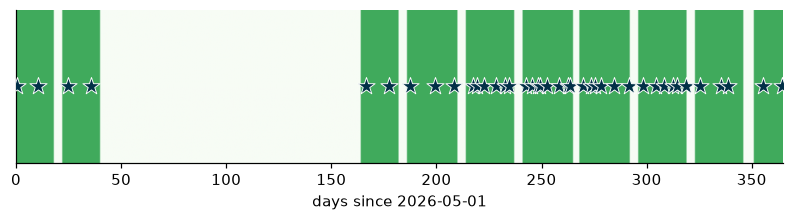

median gap: 6.0 d


In [8]:
final = plan_calendar(
    n_obs=40,
    periods_d=demo_period_d,
    season_start=season_start,
    season_end=season_end,
    target_coord=target_coord,
    observer_location=observer_location,
    min_moon_sep_deg=30.0,
    min_altitude_deg=30.0,
)

allowed_all = sorted(moon_allowed & vis_allowed)
plot_night_availability(final, allowed_offsets=allowed_all)
plt.show()

print(f"median gap: {final.median_gap_d} d")


## Bonus 1 — how sensitive is the cadence to the altitude threshold?

`min_altitude_deg=30°` (airmass 2) is a common round-number default, but
it's worth seeing how much it actually costs versus a looser or stricter cut
before committing to it for a real campaign.

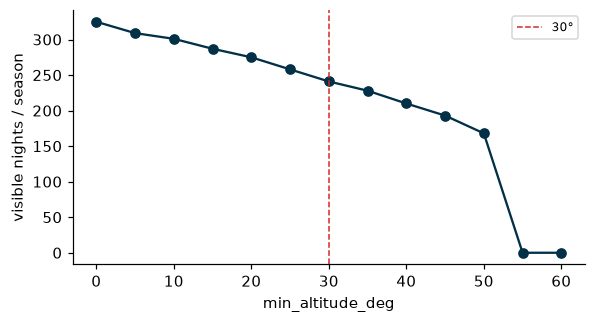

In [9]:
plot_altitude_sensitivity(final, target_coord=target_coord, observer_location=observer_location)
plt.show()


## Bonus 2 — does the greedy algorithm actually beat random dates?

A sanity check on the core claim: phase coverage from `plan_calendar`'s
greedy selection should be much more uniform than picking the same number of
dates at random from the same allowed nights.

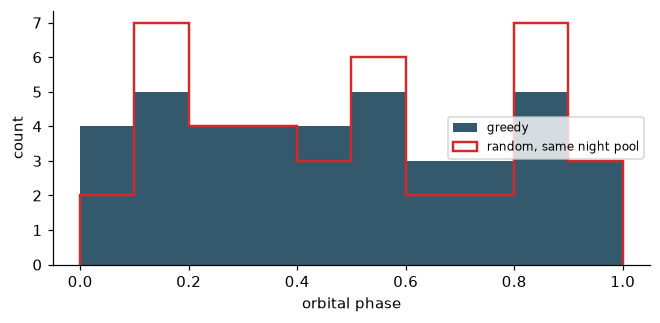

In [10]:
plot_greedy_vs_random(final, allowed_offsets=allowed_all, seed=42)
plt.show()


## 5. Mid-campaign: scheduling around what you already have

Half-way through a programme, feed the epochs already observed back in. They
are locked in place, and only the remaining budget is optimized — the orange
epochs below are fixed, the dark blue ones are the new recommendation.

Every new epoch falls after the last observed one: you cannot go back in
time and take a spectrum, so the past is cut out of the candidate pool. If
planning resumes later than your last observation, pass `schedule_from=` —
the gap since then is invisible to the default cutoff.


15 locked, 25 still to observe
first new epoch: 2027-01-01 (last observed: 2026-12-21)


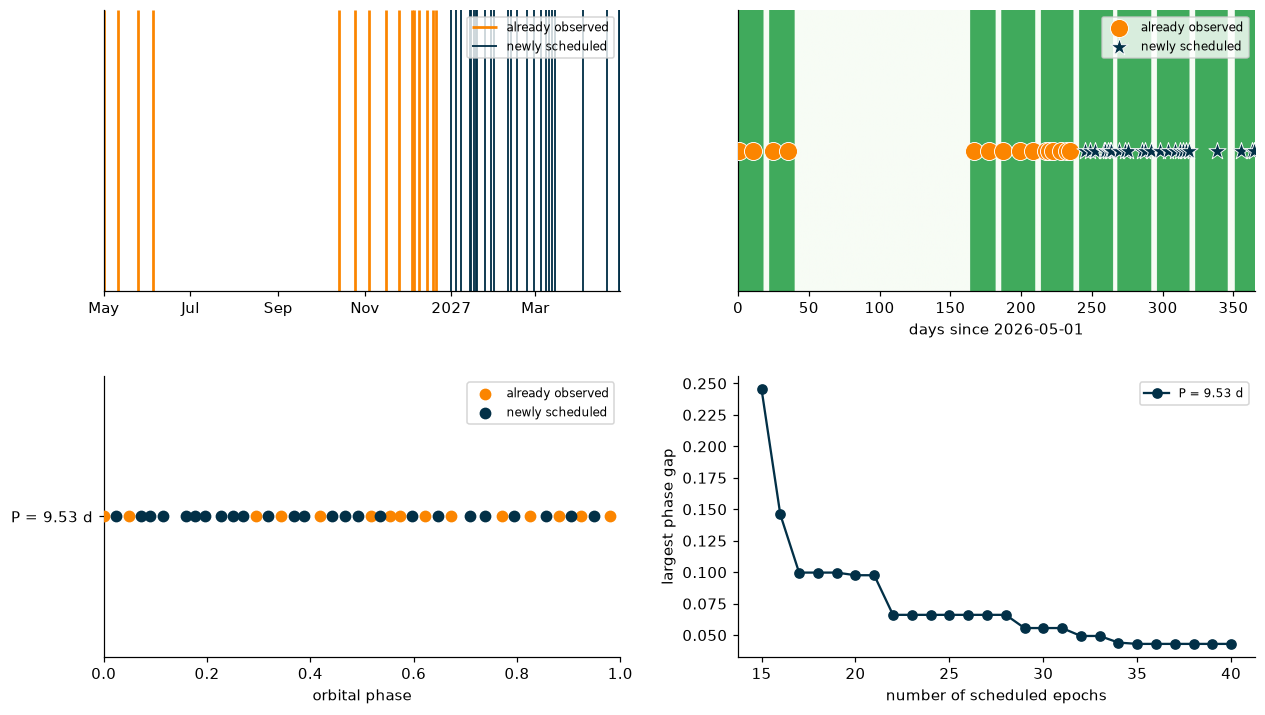

In [11]:
already_observed = [d.isoformat() for d in final.dates[:15]]

updated = plan_calendar(
    n_obs=40,
    periods_d=demo_period_d,
    season_start=season_start,
    season_end=season_end,
    target_coord=target_coord,
    observer_location=observer_location,
    min_moon_sep_deg=30.0,
    min_altitude_deg=30.0,
    existing_times=already_observed,
)

print(f"{len(updated.locked_dates)} locked, {updated.n_remaining} still to observe")
print(f"first new epoch: {min(updated.new_dates)} (last observed: {max(updated.locked_dates)})")
plot_summary(updated, allowed_offsets=allowed_all)
plt.show()


## 6. Tuning the score

`weights` sets the balance between planet-phase, rotation-phase and temporal
spread; `planet_weights` says which planet's phase completion matters most.
The phase-vs-rotation-phase panel shows whether the cadence aliases the planet
signal onto the activity signal — points along a diagonal mean the two will be
hard to separate in the RV fit.


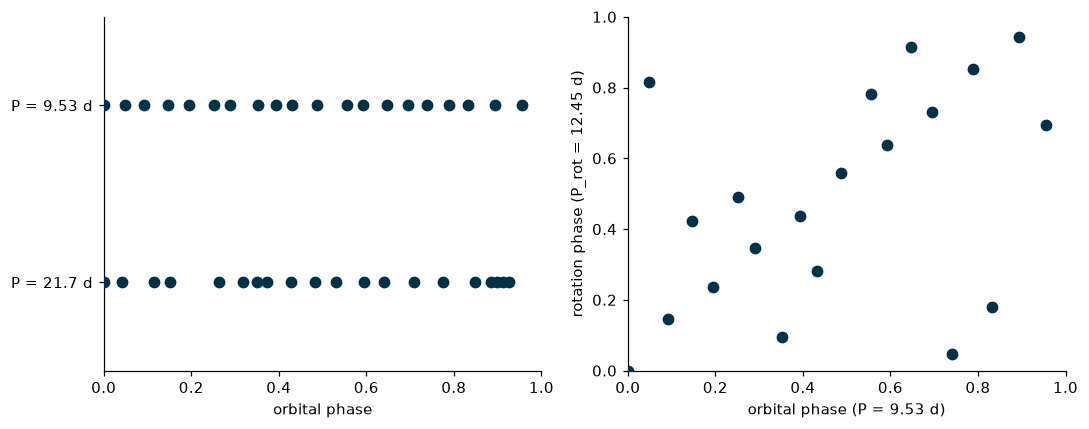

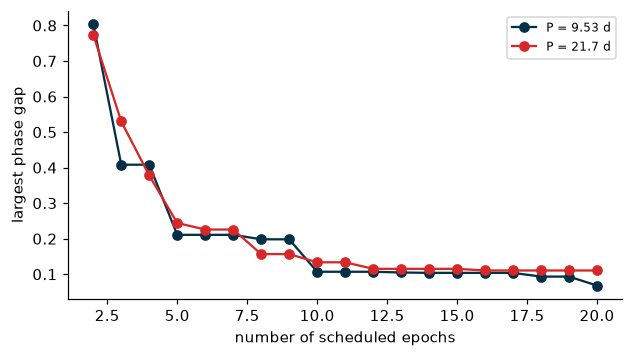

In [12]:
tuned = plan_calendar(
    n_obs=20,
    periods_d=periods_multi,
    season_start=season_start,
    season_end=season_end,
    rotation_period_d=p_rot_d,
    weights=(0.70, 0.20, 0.10),
    planet_weights=[0.75, 0.25],
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_phase_coverage(tuned, ax=axes[0])
plot_phase_vs_rotation_phase(tuned, ax=axes[1])
fig.tight_layout()
plt.show()

plot_coverage_vs_n(tuned)
plt.show()
